# Computational Model of Clock Timing Error During GNSS Holdover

## 1. Introduction

This notebook develops a model to estimate accumulated timing error during GNSS holdover for a chip-scale atomic clock (CSAC) and a temperature-compensated crystal oscillator (TCXO).

Published device specifications and clock-characterisation data are used to model deterministic and stochastic contributions separately and compare their influence on holdover performance.


## 2. Physical Problem

During normal operation, a local oscillator can be referenced to GNSS timing. When the GNSS reference becomes unavailable, the oscillator enters holdover and must maintain timing independently.

Small deviations from the nominal oscillator frequency accumulate into timing error. The fractional frequency error is

$$
y(t)=\frac{f(t)-f_0}{f_0},
$$

where $f(t)$ is the actual frequency, $f_0$ is the nominal frequency, and $y(t)$ is the dimensionless fractional frequency error.

Clock error can arise from deterministic effects, such as initial frequency offset, ageing and temperature dependence, as well as stochastic frequency fluctuations. These contributions are treated separately in the model.


## 3. Mathematical Model

### 3.1 Accumulated Timing Error

Accumulated timing error is obtained by integrating fractional frequency error:

$$
x(t)=x(0)+\int_0^t y(\tau)\,d\tau.
$$

The start of holdover is used as the timing reference,

$$
x(0)=0,
$$

so $x(t)$ represents the additional timing error accumulated after the GNSS reference is lost.


### 3.2 Clock Error Components

The fractional frequency error is represented as

$$
y(t)
=
y_0
+
y_{\mathrm{age}}(t)
+
y_T(t)
+
y_{\mathrm{stoch}}(t),
$$

where $y_0$ is the residual initial frequency offset, $y_{\mathrm{age}}(t)$ represents ageing, $y_T(t)$ represents temperature-dependent variation, and $y_{\mathrm{stoch}}(t)$ represents stochastic frequency instability.

Therefore,

$$
x(t)
=
\int_0^t
\left[
y_0
+
y_{\mathrm{age}}(\tau)
+
y_T(\tau)
+
y_{\mathrm{stoch}}(\tau)
\right]d\tau.
$$

The contributions are evaluated separately before their implications for holdover performance are compared.


### 3.3 Constant Frequency Offset

For a constant fractional frequency offset,

$$
y(t)=y_0,
$$

the accumulated timing error is

$$
x_{\mathrm{offset}}(t)=y_0t.
$$

The timing error therefore increases linearly with holdover duration.


### 3.4 Linear Frequency Drift

For a linear fractional frequency drift,

$$
y(t)=y_0+Dt,
$$

where $D$ is the fractional-frequency drift rate. Integration gives

$$
x(t)=y_0t+\frac{1}{2}Dt^2.
$$

The offset contribution therefore grows linearly with time, while the linear-drift contribution grows quadratically.

## 4. Model Parameters and Data Sources

The model uses two types of clock data: **deterministic parameters** and **stochastic parameters**.

Deterministic parameters describe frequency offset, ageing and temperature effects and are taken from manufacturer datasheets. Stochastic parameters describe random frequency fluctuations and are taken from published clock-characterisation studies because the selected datasheets do not provide all the information needed to model clock noise.

The Microchip SA.45s is used as the representative CSAC. For the TCXO comparison, manufacturer specifications are taken from the IQD IQXT-220-1 datasheet. Stochastic noise parameters for both clock types are taken from Fernández et al. (2017).


### 4.1 Deterministic Parameters

The deterministic parameters are taken from the **Microchip SA.45s CSAC Options 001 and 003 datasheet** and the **IQD IQXT-220-1 TCXO datasheet**.

| Parameter | SA.45s CSAC | Representative TCXO | Intended use |
|---|---:|---:|---|
| Frequency offset/tolerance | $\pm5\times10^{-11}$ | $\pm1.00$ ppm | Initial-offset sensitivity |
| Ageing | $<9\times10^{-10}$/month | $\pm0.02$ ppm/day maximum | Ageing analysis |
| Long-term ageing | — | $\pm1$ ppm/year maximum | Reference only |
| Temperature-related frequency variation | $\pm5\times10^{-10}$ | $\pm0.28$ ppm | Temperature bounding analysis |

For calculation, the TCXO values are converted to fractional-frequency units:

$$
0.28\ \mathrm{ppm}=2.8\times10^{-7},
$$

and

$$
0.02\ \mathrm{ppm/day}=2.0\times10^{-8}\ \mathrm{day}^{-1}.
$$

The parameters are used in the model as follows:

- **Frequency offset:** The SA.45s value is specified at shipment, while the TCXO value is a manufacturer frequency tolerance. Neither gives the actual residual frequency offset $y_0$ after GNSS disciplining. Therefore, these values are not assigned directly to $y_0$. Initial offset is examined separately through sensitivity analysis.

- **Ageing:** The ageing specifications are used to model gradual frequency change during holdover. The TCXO long-term ageing value is kept as reference information but is not used because the model considers holdover periods of up to 12 hours.

- **Temperature:** The temperature specifications describe frequency variation over the stated operating-temperature ranges. Since the actual temperature profile during holdover is unknown, these values are used as bounding cases rather than expected constant frequency errors.


### 4.2 Stochastic Parameters

Random frequency fluctuations are represented using the fractional-frequency power spectral density model reported by Fernández, Calero and Parés (2017):

$$
S_y(f)
=
h_0
+
h_{-1}f^{-1}
+
h_{-2}f^{-2},
$$

where:

- $h_0$ represents **white frequency noise**, describing rapid random changes in frequency.
- $h_{-1}$ represents **flicker frequency noise**, describing slower frequency fluctuations.|
- $h_{-2}$ represents **random-walk frequency noise**, describing frequency changes that accumulate over time.

The stochastic coefficients for both clock types are taken from **Fernández et al. (2017), Table 1**.

| Noise coefficient | Representative CSAC | Representative TCXO | Noise type |
|---|---:|---:|---|
| $h_0$ | $7.2\times10^{-21}$ | $9.4\times10^{-20}$ | White FM |
| $h_{-1}$ | $2.6\times10^{-23}$ | $1.8\times10^{-19}$ | Flicker FM |
| $h_{-2}$ | $2.7\times10^{-27}$ | $3.8\times10^{-21}$ | Random-walk FM |

Fernández et al. (2017) describe these coefficients as generic values obtained from manufacturer information under unspecified operating conditions. They are therefore used to represent general CSAC and TCXO stochastic behaviour rather than direct measurements of the specific SA.45s and IQD IQXT-220-1 devices.


#### 4.2.1 From Noise Coefficients to Allan Deviation

The coefficients $h_0$, $h_{-1}$ and $h_{-2}$ are converted to Allan variance using the standard relationships between power-law frequency noise and Allan variance.

For the three noise processes considered here, the contributions are

$$
\sigma^2_{y,\mathrm{white}}(\tau)
=
\frac{h_0}{2\tau},
$$

$$
\sigma^2_{y,\mathrm{flicker}}(\tau)
=
2\ln(2)h_{-1},
$$

and

$$
\sigma^2_{y,\mathrm{{random\ walk}}}(\tau)
=
\frac{2\pi^2}{3}h_{-2}\tau.
$$

The combined Allan variance is therefore

$$
\sigma_y^2(\tau)
=
\frac{h_0}{2\tau}
+
2\ln(2)h_{-1}
+
\frac{2\pi^2}{3}h_{-2}\tau.
$$

The Allan deviation is then calculated as

$$
\sigma_y(\tau)
=
\sqrt{\sigma_y^2(\tau)}.
$$

This allows the stochastic coefficients to be expressed as frequency stability as a function of averaging time $\tau$.


#### 4.2.2 Reported Allan-Deviation Data

Independent stability data are kept for comparison with the Allan deviation calculated from the stochastic coefficients.

The SA.45s datasheet provides:

| Averaging time $\tau$ | SA.45s Allan deviation |
|---:|---:|
| 1 s | $3\times10^{-10}$ |
| 10 s | $1\times10^{-10}$ |
| 100 s | $3\times10^{-11}$ |
| 1000 s | $1\times10^{-11}$ |

For the TCXO, Calero and Fernández (2015) report a short-term fractional-frequency stability of approximately

$$
\sigma_y(1\,\mathrm{s})
\approx
2\times10^{-9}
$$

for the TCXO used in their GNSS receiver.

These reported values are **not used to construct the stochastic model**. The stochastic model is calculated from $h_0$, $h_{-1}$ and $h_{-2}$. The calculated Allan deviation is then compared with the reported values as a consistency check.

The TCXO value from Calero and Fernández (2015) is not treated as a specification of the IQD IQXT-220-1. It is used only as an independent reference for representative TCXO short-term stability.


### 4.3 Experimental Evidence for Model Assessment

Experimental observations from Calero and Fernández (2015) and Fernández et al. (2017), including free-running clock behaviour, temperature effects, ageing and GNSS holdover behaviour, are kept for later comparison with the computational results.

These observations are not used to construct the model. Keeping them separate allows the calculated results to be compared with independent published clock behaviour.

## 5. Computational Setup and Parameter Conversion

Before implementing the timing-error model, the published clock specifications must be converted into consistent units. The simulation uses seconds as the time variable and dimensionless fractional frequency for oscillator error.

The baseline simulation assumes that both clocks enter holdover immediately after GNSS disciplining. Therefore, the initial accumulated timing error is defined as

$$
x(0)=0.
$$

The residual fractional frequency offset is initially set to

$$
y_0 = 0
$$

because the actual post-disciplining offset is unknown. This avoids assigning an unsupported value to the baseline model. 


### 5.1 Holdover Durations

The representative GNSS outage durations considered in the model are

| Holdover interval | Time (s) |
|---|---:|
| 10 min | 600 |
| 1 h | 3600 |
| 6 h | 21600 |
| 12 h | 43200 |


### 5.2 Ageing-Rate Conversion

The TCXO ageing specification is

$$
0.02\ \mathrm{ppm/day}.
$$

Since

$$
1\ \mathrm{ppm}=10^{-6},
$$

the fractional-frequency change per day is

$$
0.02\times10^{-6}=2.0\times10^{-8}.
$$

Converting from per day to per second gives

$$
D_{\mathrm{TCXO}}
=
\frac{2.0\times10^{-8}}{86400}
\approx2.31\times10^{-13}\ \mathrm{s^{-1}}.
$$

The SA.45s ageing specification is

$$
9\times10^{-10}/\mathrm{month}.
$$

For the computational model, one month is approximated as 30 days:

$$
30\times86400=2\,592\,000\ \mathrm{s}.
$$

Therefore,

$$
D_{\mathrm{CSAC}}
=
\frac{9\times10^{-10}}{2\,592\,000}
\approx3.47\times10^{-16}\ \mathrm{s^{-1}}.
$$

These converted ageing rates can be used in the linear-drift timing-error expression

$$
x_{\mathrm{age}}(t)=\frac{1}{2}Dt^2.
$$

In [2]:
# 5. Computational Setup and Parameter Conversion

# Number of seconds used for unit conversions
SECONDS_PER_DAY = 24 * 60 * 60
SECONDS_PER_MONTH = 30 * SECONDS_PER_DAY

# Holdover durations

holdover_times = {
    "10 min": 10 * 60,
    "1 h": 1 * 60 * 60,
    "6 h": 6 * 60 * 60,
    "12 h": 12 * 60 * 60
}


# Timing error is measured relative to the start of holdover.
x0 = 0.0  # seconds

# Baseline assumption

y0_csac = 0.0
y0_tcxo = 0.0

# CSAC parameters

csac_ageing_per_month = 9e-10

D_csac = csac_ageing_per_month / SECONDS_PER_MONTH

csac_temperature_limit = 5e-10

# TCXO parameters
tcxo_ageing_ppm_per_day = 0.02

tcxo_ageing_per_day = tcxo_ageing_ppm_per_day * 1e-6
D_tcxo = tcxo_ageing_per_day / SECONDS_PER_DAY
tcxo_temperature_ppm = 0.28
tcxo_temperature_limit = tcxo_temperature_ppm * 1e-6

# Display converted parameters
print("Holdover durations:")
for label, time_s in holdover_times.items():
    print(f"  {label:6s}: {time_s:8d} s")

print("\nInitial conditions:")
print(f"  x0       = {x0:.1f} s")
print(f"  CSAC y0  = {y0_csac:.1e}")
print(f"  TCXO y0  = {y0_tcxo:.1e}")

print("\nConverted ageing rates:")
print(f"  CSAC D   = {D_csac:.3e} s^-1")
print(f"  TCXO D   = {D_tcxo:.3e} s^-1")

print("\nTemperature stability limits:")
print(f"  CSAC     = +/- {csac_temperature_limit:.3e}")
print(f"  TCXO     = +/- {tcxo_temperature_limit:.3e}")

Holdover durations:
  10 min:      600 s
  1 h   :     3600 s
  6 h   :    21600 s
  12 h  :    43200 s

Initial conditions:
  x0       = 0.0 s
  CSAC y0  = 0.0e+00
  TCXO y0  = 0.0e+00

Converted ageing rates:
  CSAC D   = 3.472e-16 s^-1
  TCXO D   = 2.315e-13 s^-1

Temperature stability limits:
  CSAC     = +/- 5.000e-10
  TCXO     = +/- 2.800e-07


## 6. Deterministic Timing Error Model

The deterministic component of the holdover model is evaluated before introducing stochastic clock noise. This allows the contribution of each systematic effect to accumulated timing error to be examined independently.

### 6.1 Timing Error Due to Ageing

The ageing specification describes a gradual change in oscillator fractional frequency with time. For a simplified linear ageing model,

$$
y_{\mathrm{age}}(t)=Dt,
$$

where $D$ is the fractional-frequency ageing rate.

The corresponding accumulated timing error is obtained by integration:

$$
x_{\mathrm{age}}(t)
=
\int_0^t D\tau\,d\tau
=
\frac{1}{2}Dt^2.
$$

This model assumes that the published ageing rate can be represented as a constant linear rate over the holdover interval. This is an approximation because physical oscillator ageing may not be perfectly linear.

For the SA.45s, the manufacturer ageing specification is a maximum limit of

$$
9\times10^{-10}/\mathrm{month},
$$

while the representative IQD TCXO specifies a maximum ageing of

$$
0.02\ \mathrm{ppm/day}.
$$

The converted rates from Section 5 are used to estimate the corresponding timing-error contribution over the selected holdover intervals.

In [3]:
# 6.1 Timing Error Due to Ageing

import pandas as pd

def ageing_timing_error(D, t):
    """
    Calculate accumulated timing error caused by linear ageing.

    Parameters
    ----------
    D : float
        Fractional-frequency ageing rate in s^-1.
    t : float
        Holdover duration in seconds.

    Returns
    -------
    float
        Accumulated timing error in seconds.
    """
    return 0.5 * D * t**2


# Calculate ageing timing error for each holdover interval
ageing_results = []

for label, t in holdover_times.items():

    x_age_csac = ageing_timing_error(D_csac, t)
    x_age_tcxo = ageing_timing_error(D_tcxo, t)

    ageing_results.append({
        "Holdover": label,
        "Time (s)": t,
        "CSAC ageing error (s)": x_age_csac,
        "TCXO ageing error (s)": x_age_tcxo
    })


# Convert results to a DataFrame
ageing_df = pd.DataFrame(ageing_results)

ageing_df

,Holdover,Time (s),CSAC ageing error (s),TCXO ageing error (s)
0,10 min,600,6.250000e-11,4.166667e-08
1,1 h,3600,2.250000e-09,1.500000e-06
2,6 h,21600,8.100000e-08,5.400000e-05
3,12 h,43200,3.240000e-07,2.160000e-04


In [4]:
# Create a display table using microseconds

ageing_display = ageing_df.copy()

ageing_display["CSAC ageing error (us)"] = (
    ageing_display["CSAC ageing error (s)"] * 1e6
)

ageing_display["TCXO ageing error (us)"] = (
    ageing_display["TCXO ageing error (s)"] * 1e6
)

ageing_display[
    [
        "Holdover",
        "CSAC ageing error (us)",
        "TCXO ageing error (us)"
    ]
]

,Holdover,CSAC ageing error (us),TCXO ageing error (us)
0,10 min,0.000062,0.041667
1,1 h,0.002250,1.500000
2,6 h,0.081000,54.000000
3,12 h,0.324000,216.000000


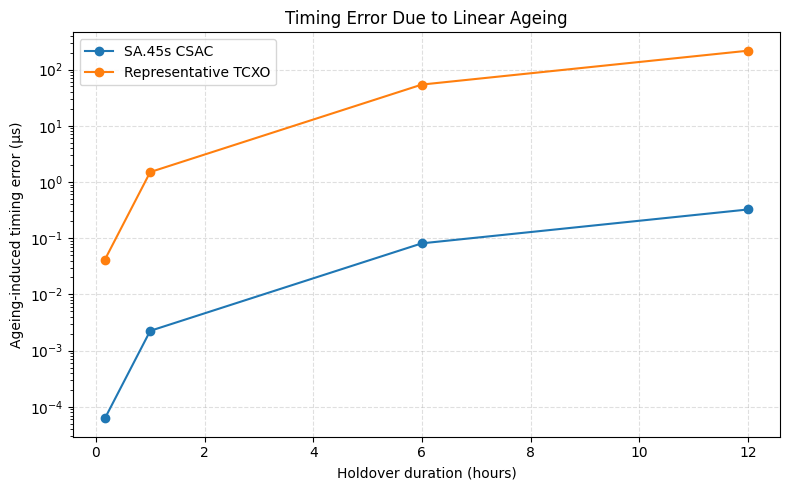

In [5]:
import matplotlib.pyplot as plt

time_hours = ageing_df["Time (s)"] / 3600
csac_age_us = ageing_df["CSAC ageing error (s)"] * 1e6
tcxo_age_us = ageing_df["TCXO ageing error (s)"] * 1e6

plt.figure(figsize=(8, 5))

plt.plot(
    time_hours,
    csac_age_us,
    marker="o",
    label="SA.45s CSAC"
)

plt.plot(
    time_hours,
    tcxo_age_us,
    marker="o",
    label="Representative TCXO"
)

# Logarithmic y-axis
plt.yscale("log")

plt.xlabel("Holdover duration (hours)")
plt.ylabel("Ageing-induced timing error (µs)")
plt.title("Timing Error Due to Linear Ageing")

# Show only major grid lines
plt.grid(True, which="major", linestyle="--", alpha=0.4)

plt.legend()
plt.tight_layout()

plt.show()

### 6.1.1 Interpretation of Ageing Results

The ageing model predicts a substantially smaller accumulated timing-error contribution for the SA.45s CSAC than for the representative TCXO over all investigated holdover intervals.

Because ageing is represented by

$$
x_{\mathrm{age}}(t)=\frac{1}{2}Dt^2,
$$

the timing error increases quadratically with holdover duration. Therefore, the effect of ageing becomes increasingly important as the GNSS outage becomes longer.

At 12 hours, the calculated ageing-induced timing errors are approximately

$$
x_{\mathrm{age,CSAC}}=0.324\ \mu\mathrm{s}
$$

and

$$
x_{\mathrm{age,TCXO}}=216\ \mu\mathrm{s}.
$$

A logarithmic vertical scale is used in the figure because the ageing contributions of the two clocks differ by several orders of magnitude. On a linear scale, the smaller CSAC contribution would be visually compressed near zero.

These results represent only the **ageing contribution** to timing error. They should not be interpreted as the total holdover error of either clock. The calculation also assumes that the manufacturer ageing limits can be represented by constant linear ageing rates over the holdover interval.

Residual frequency offset, temperature-dependent frequency variation and stochastic frequency instability are considered separately in the following sections.

### 6.2 Timing Error Due to Initial Frequency Offset

A clock may enter holdover with a residual fractional-frequency offset relative to its ideal reference frequency. If this offset remains approximately constant during holdover,

$$
y(t)=y_0,
$$

the accumulated timing error is

$$
x_{\mathrm{offset}}(t)
=
\int_0^t y_0\,d\tau
=
y_0t.
$$

Unlike the ageing contribution, which increases as $t^2$ under the linear-ageing approximation, timing error caused by a constant initial frequency offset increases linearly with holdover duration.

For the baseline model, the residual frequency offset is set to

$$
y_0=0
$$

for both clocks. This represents an idealised condition in which the clocks enter holdover immediately after GNSS disciplining with no residual frequency offset.

The manufacturer specifications listed in Section 4 are not directly assigned to $y_0$. In particular, the SA.45s frequency offset at shipment and the IQD TCXO frequency tolerance describe manufacturer-specified device performance rather than the residual frequency offset immediately following GNSS disciplining.

Therefore, these values are not included in the baseline holdover calculation. Instead, the influence of a non-zero initial frequency offset is examined through a separate sensitivity analysis.


#### 6.2.1 Initial-Offset Sensitivity Analysis

To determine how strongly holdover performance depends on the initial frequency condition, several hypothetical residual fractional-frequency offsets are considered:

$$
|y_0|
=
10^{-12},\;
10^{-11},\;
10^{-10},\;
10^{-9}.
$$

These values are not assigned as measured properties of either the SA.45s or the representative TCXO. They are used only as sensitivity cases to demonstrate how different residual frequency offsets propagate into accumulated timing error.

For each case,

$$
|x_{\mathrm{offset}}(t)|
=
|y_0|t.
$$

Using the magnitude of the error allows the sensitivity analysis to focus on the size of the accumulated timing error rather than whether the oscillator is running slightly faster or slower than the reference.

In [6]:
# 6.2 Initial Frequency Offset Sensitivity Analysis

import pandas as pd

def offset_timing_error(y0, t):
    """
    Calculate accumulated timing error caused by a constant
    fractional-frequency offset.

    Parameters
    ----------
    y0 : float
        Initial fractional-frequency offset.
    t : float
        Holdover duration in seconds.

    Returns
    -------
    float
        Accumulated timing error in seconds.
    """
    return abs(y0) * t


# Hypothetical residual frequency offsets used only
# for sensitivity analysis
y0_cases = [
    1e-12,
    1e-11,
    1e-10,
    1e-9
]

offset_results = []

for label, t in holdover_times.items():

    row = {
        "Holdover": label,
        "Time (s)": t
    }

    for y0 in y0_cases:

        error_s = offset_timing_error(y0, t)

        # Store result in microseconds
        row[f"y0 = {y0:.0e} (us)"] = error_s * 1e6

    offset_results.append(row)


offset_df = pd.DataFrame(offset_results)

offset_df

,Holdover,Time (s),y0 = 1e-12 (us),y0 = 1e-11 (us),y0 = 1e-10 (us),y0 = 1e-09 (us)
0,10 min,600,0.0006,0.006,0.06,0.6
1,1 h,3600,0.0036,0.036,0.36,3.6
2,6 h,21600,0.0216,0.216,2.16,21.6
3,12 h,43200,0.0432,0.432,4.32,43.2


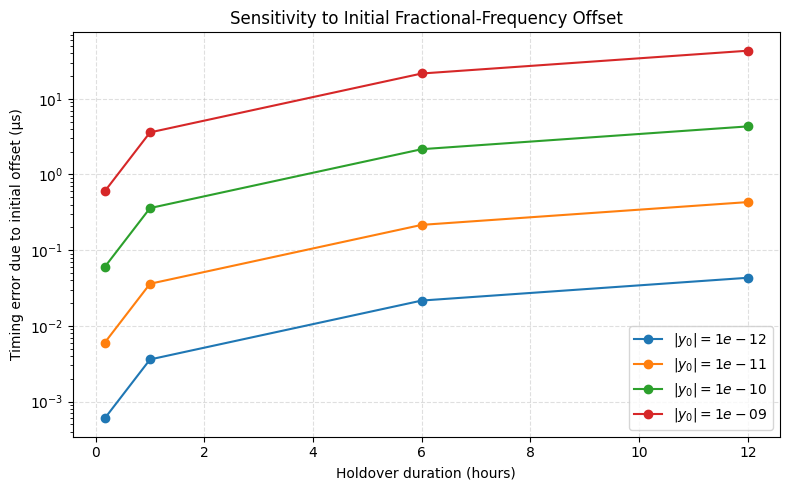

In [7]:
# 6.2.2 Initial Frequency Offset Sensitivity Plot

import matplotlib.pyplot as plt

time_hours = offset_df["Time (s)"] / 3600

plt.figure(figsize=(8, 5))

for y0 in y0_cases:

    column = f"y0 = {y0:.0e} (us)"

    plt.plot(
        time_hours,
        offset_df[column],
        marker="o",
        label=fr"$|y_0|={y0:.0e}$"
    )

plt.yscale("log")

plt.xlabel("Holdover duration (hours)")
plt.ylabel("Timing error due to initial offset (µs)")
plt.title("Sensitivity to Initial Fractional-Frequency Offset")

# Major grid lines only
plt.grid(True, which="major", linestyle="--", alpha=0.4)

plt.legend()
plt.tight_layout()

plt.show()

#### 6.2.2 Interpretation of Initial-Offset Sensitivity

The sensitivity analysis shows that accumulated timing error depends strongly on the residual fractional-frequency offset present when the clock enters holdover.

For a constant initial frequency offset,

$$
|x_{\mathrm{offset}}(t)|=|y_0|t,
$$

so the resulting timing error increases linearly with holdover duration and is directly proportional to the magnitude of $y_0$.

For example, after 12 hours of holdover,

$$
|y_0|=10^{-12}
$$

produces approximately

$$
0.0432\ \mu\mathrm{s},
$$

whereas

$$
|y_0|=10^{-10}
$$

produces

$$
4.32\ \mu\mathrm{s}.
$$

For the larger sensitivity case,

$$
|y_0|=10^{-9},
$$

the accumulated timing error reaches

$$
43.2\ \mu\mathrm{s}.
$$

These results demonstrate that even a small residual frequency offset at the beginning of holdover can become an important source of timing error during extended GNSS outages.

The sensitivity cases are not intended to represent measured values for the SA.45s or the representative TCXO. Instead, they demonstrate why the manufacturer's shipment accuracy and production frequency tolerance cannot simply be assigned as the post-disciplining value of $y_0$.

The baseline comparison therefore retains $y_0=0$ and treats uncertainty in the initial frequency condition separately from intrinsic ageing, temperature sensitivity and stochastic frequency instability.

### 6.3 Temperature-Dependent Frequency Error

Oscillator frequency can change when the operating temperature changes. This contribution is represented in the general clock model by

$$
y_T(t),
$$

where $y_T(t)$ is the fractional-frequency variation associated with temperature.

The available manufacturer specifications do not provide a complete function relating frequency to temperature. Instead, they specify maximum frequency variation over the stated operating-temperature range.

For the SA.45s CSAC, the published frequency change over the operating-temperature range is

$$
|y_{T,\mathrm{CSAC}}| \leq 5\times10^{-10}.
$$

For the representative IQD IQXT-220-1 TCXO, the published temperature stability is

$$
|y_{T,\mathrm{TCXO}}| \leq 0.28\ \mathrm{ppm}
=2.8\times10^{-7}.
$$

These values do not imply that either oscillator experiences the maximum frequency deviation continuously during a GNSS outage. The actual temperature-induced frequency error depends on the temperature history of the oscillator and its detailed frequency-temperature response.

Because a complete temperature-response function is not available from the selected datasheets, the published limits are used here as **bounding cases** rather than as predictions of expected operating behaviour.

If a constant temperature-induced fractional-frequency deviation $y_T$ were maintained throughout a holdover interval, the corresponding accumulated timing error would be

$$
x_T(t)
=
\int_0^t y_T\,d\tau
=
y_Tt.
$$

Using the magnitude of the manufacturer temperature limits therefore provides an upper-bound sensitivity calculation:

$$
|x_T(t)|=|y_T|t.
$$

This calculation is used to examine the potential importance of temperature sensitivity. It is not included directly in the nominal holdover prediction because the actual temperature trajectory during the underwater mission has not been specified.

In [8]:
# 6.3 Temperature-Dependent Frequency Error
# Bounding-case sensitivity analysis

import pandas as pd
def temperature_timing_error(y_temp, t):
    """
    Calculate accumulated timing error for a constant
    temperature-induced fractional-frequency deviation.

    Parameters
    ----------
    y_temp : float
        Magnitude of fractional-frequency deviation caused
        by temperature.
    t : float
        Holdover duration in seconds.

    Returns
    -------
    float
        Accumulated timing-error magnitude in seconds.
    """
    return abs(y_temp) * t


temperature_results = []

for label, t in holdover_times.items():

    x_temp_csac = temperature_timing_error(
        csac_temperature_limit,
        t
    )

    x_temp_tcxo = temperature_timing_error(
        tcxo_temperature_limit,
        t
    )

    temperature_results.append({
        "Holdover": label,
        "Time (s)": t,
        "CSAC temperature bound (us)": x_temp_csac * 1e6,
        "TCXO temperature bound (us)": x_temp_tcxo * 1e6
    })


temperature_df = pd.DataFrame(temperature_results)

temperature_df

,Holdover,Time (s),CSAC temperature bound (us),TCXO temperature bound (us)
0,10 min,600,0.3,168.0
1,1 h,3600,1.8,1008.0
2,6 h,21600,10.8,6048.0
3,12 h,43200,21.6,12096.0


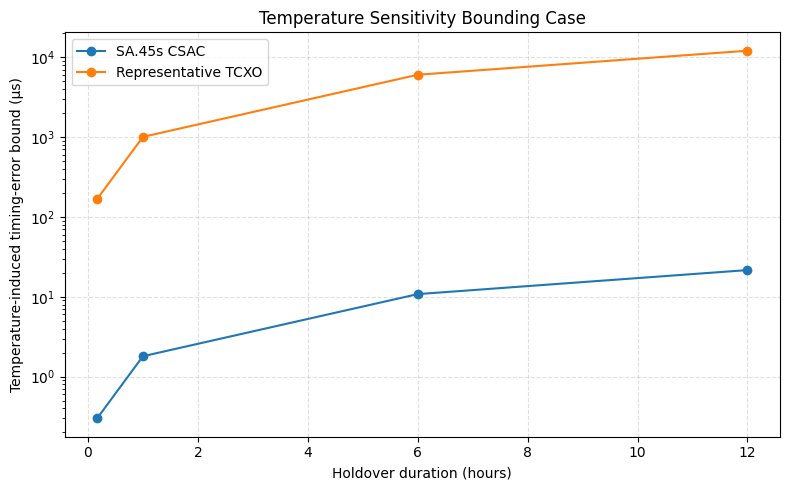

In [9]:
# 6.3.1 Temperature Sensitivity Plot
import matplotlib.pyplot as plt

time_hours = temperature_df["Time (s)"] / 3600

plt.figure(figsize=(8, 5))

plt.plot(
    time_hours,
    temperature_df["CSAC temperature bound (us)"],
    marker="o",
    label="SA.45s CSAC"
)

plt.plot(
    time_hours,
    temperature_df["TCXO temperature bound (us)"],
    marker="o",
    label="Representative TCXO"
)

plt.yscale("log")

plt.xlabel("Holdover duration (hours)")
plt.ylabel("Temperature-induced timing-error bound (µs)")
plt.title("Temperature Sensitivity Bounding Case")

plt.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()

plt.show()

#### 6.3.1 Interpretation of Temperature Sensitivity

The bounding calculation shows that the representative TCXO has a substantially larger manufacturer-specified frequency variation over its operating-temperature range than the SA.45s CSAC.

At 12 hours, maintaining the full specified temperature-related fractional-frequency deviation throughout the holdover interval would correspond to timing-error bounds of approximately

$$
21.6\ \mu\mathrm{s}
$$

for the SA.45s and

$$
12.096\ \mathrm{ms}
$$

for the representative TCXO.

These values should **not** be interpreted as expected timing errors during the underwater mission. The manufacturer specifications describe frequency variation over an operating-temperature range and do not specify that the maximum deviation persists continuously.

The calculation therefore demonstrates the sensitivity of accumulated timing error to temperature-dependent frequency variation rather than predicting a specific mission temperature error.

A realistic temperature contribution would require a time-dependent temperature profile $T(t)$ together with a measured or manufacturer-specified frequency-temperature relationship for each oscillator. Since these data are not available for both selected devices, the temperature contribution is retained as a separate bounding analysis rather than being added directly to the nominal holdover model.

# 7. Stochastic Clock Noise

The deterministic analyses in Section 6 considered systematic contributions from ageing, initial frequency offset and temperature sensitivity. Real oscillators also exhibit random frequency fluctuations, represented here by the stochastic term

$$
y_{\mathrm{stoch}}(t).
$$

Fernández et al. (2017) describe fractional-frequency noise using the power spectral density

$$
S_y(f)=h_0+h_{-1}f^{-1}+h_{-2}f^{-2},
$$

where:

- $h_0$ represents white frequency-modulation (white FM) noise,
- $h_{-1}$ represents flicker frequency-modulation (flicker FM) noise, and
- $h_{-2}$ represents random-walk frequency-modulation (random-walk FM) noise.

These noise processes affect clock stability differently as the averaging time increases.


## 7.1 Connection to Allan Deviation

Clock frequency stability is characterised using Allan deviation,

$$
\sigma_y(\tau),
$$

where $\tau$ is the averaging time.

For the three power-law noise processes considered here, the Allan variance is

$$
\sigma_y^2(\tau)
=
\frac{h_0}{2\tau}
+
2\ln(2)h_{-1}
+
\frac{2\pi^2}{3}h_{-2}\tau.
$$

Therefore,

$$
\sigma_y(\tau)
=
\sqrt{
\frac{h_0}{2\tau}
+
2\ln(2)h_{-1}
+
\frac{2\pi^2}{3}h_{-2}\tau
}.
$$

The individual contributions scale as

$$
\sigma_{y,\mathrm{white}}(\tau)\propto\tau^{-1/2},
$$

$$
\sigma_{y,\mathrm{flicker}}(\tau)\propto\tau^0,
$$

and

$$
\sigma_{y,\mathrm{RW}}(\tau)\propto\tau^{1/2}.
$$

Thus, white FM is most important at short averaging times, flicker FM produces an approximately constant stability floor, and random-walk FM becomes increasingly important at longer averaging times.

The published noise coefficients are first converted to Allan deviation before estimating their timing implications.

In [10]:
# 7.1 Stochastic Clock-Noise Parameters

import numpy as np
import pandas as pd

noise_parameters = {
    "Representative CSAC": {
        "h0": 7.2e-21,
        "h_minus1": 2.6e-23,
        "h_minus2": 2.7e-27
    },

    "Representative TCXO": {
        "h0": 9.4e-20,
        "h_minus1": 1.8e-19,
        "h_minus2": 3.8e-21
    }
}

noise_parameters

{'Representative CSAC': {'h0': 7.2e-21,
  'h_minus1': 2.6e-23,
  'h_minus2': 2.7e-27},
 'Representative TCXO': {'h0': 9.4e-20,
  'h_minus1': 1.8e-19,
  'h_minus2': 3.8e-21}}

In [11]:
# Allan deviation calculated from the power-law noise model

def allan_deviation(tau, h0, h_minus1, h_minus2):
    """
    Calculate Allan deviation for white FM, flicker FM,
    and random-walk FM noise.
    """

    white_fm = h0 / (2 * tau)

    flicker_fm = (
        2 * np.log(2) * h_minus1
    )

    random_walk_fm = (
        (2 * np.pi**2 / 3) * h_minus2 * tau
    )

    allan_variance = (
        white_fm
        + flicker_fm
        + random_walk_fm
    )

    return np.sqrt(allan_variance)

In [12]:
# Averaging times used for stability comparison

tau_values = np.array([
    1,
    10,
    100,
    1000
], dtype=float)

allan_results = []

for tau in tau_values:

    row = {
        "Tau (s)": tau
    }

    for clock_name, p in noise_parameters.items():

        sigma = allan_deviation(
            tau,
            p["h0"],
            p["h_minus1"],
            p["h_minus2"]
        )

        row[clock_name] = sigma

    allan_results.append(row)

allan_df = pd.DataFrame(allan_results)

allan_df

,Tau (s),Representative CSAC,Representative TCXO
0,1.0,6.029976e-11,5.670414e-10
1,10.0,1.990531e-11,7.101148e-10
2,100.0,8.591867e-12,1.658404e-09
3,1000.0,7.576869e-12,5.025194e-09


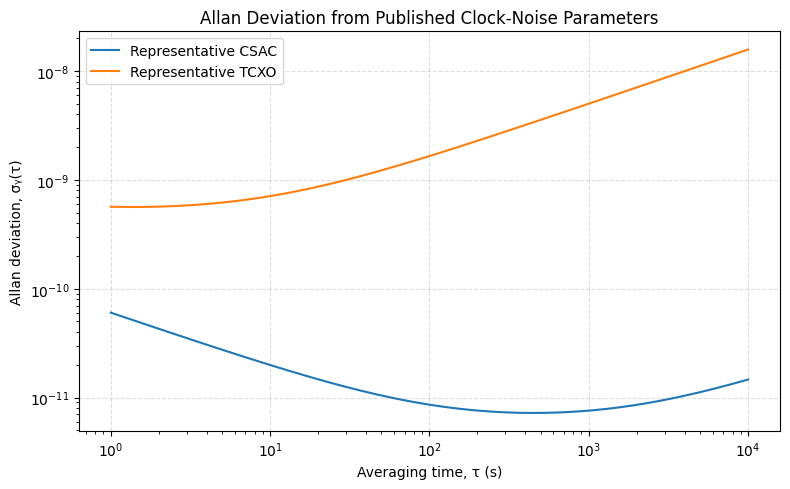

In [13]:
# 7.1.1 Allan Deviation from Published Noise Coefficients
import matplotlib.pyplot as plt

tau_plot = np.logspace(0, 4, 200)

plt.figure(figsize=(8, 5))

for clock_name, p in noise_parameters.items():

    sigma = allan_deviation(
        tau_plot,
        p["h0"],
        p["h_minus1"],
        p["h_minus2"]
    )

    plt.loglog(
        tau_plot,
        sigma,
        label=clock_name
    )

plt.xlabel("Averaging time, τ (s)")
plt.ylabel("Allan deviation, σᵧ(τ)")
plt.title("Allan Deviation from Published Clock-Noise Parameters")

plt.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()

plt.show()

### 7.1.1 Comparison with Reported Stability

The calculated Allan deviation shows lower fractional-frequency instability for the representative CSAC model than for the representative TCXO model.

At $\tau=1$ s, the noise coefficients give

$$
\sigma_{y,\mathrm{CSAC}}\approx6.03\times10^{-11}
$$

and

$$
\sigma_{y,\mathrm{TCXO}}\approx5.67\times10^{-10}.
$$

For comparison, the SA.45s datasheet specifies

$$
\sigma_y(1\ \mathrm{s})=3\times10^{-10}.
$$

The difference indicates that the Fernández et al. (2017) CSAC coefficients should not be interpreted as a fitted noise model for the specific SA.45s device. They are retained as a representative CSAC stochastic model.

At longer averaging times, the TCXO Allan deviation increases more strongly because of its larger random-walk FM contribution. The calculated curves therefore provide a representative comparison of the stochastic stability behaviour of the two clock classes rather than exact predictions for the selected commercial devices.

## 7.2 Statistical Representation of Stochastic Timing Error

Unlike deterministic effects, stochastic frequency fluctuations do not produce a single predictable timing-error trajectory. Their timing impact is therefore represented statistically.

A simple timing-uncertainty scale can be estimated from the Allan deviation using

$$
\sigma_x(\tau)\approx\tau\sigma_y(\tau).
$$

This provides an order-of-magnitude indication of the timing uncertainty associated with frequency instability over the corresponding interval. It is not an exact prediction of accumulated clock phase error.

The estimate is evaluated at holdover durations of 10 minutes, 1 hour, 6 hours and 12 hours using the representative noise coefficients from Fernández et al. (2017).

In [14]:
# 7.2 Statistical Stochastic Timing-Error Estimate

stochastic_results = []

for label, t in holdover_times.items():

    row = {
        "Holdover": label,
        "Time (s)": t
    }

    for clock_name, p in noise_parameters.items():

        # Allan deviation at the holdover interval
        sigma_y = allan_deviation(
            t,
            p["h0"],
            p["h_minus1"],
            p["h_minus2"]
        )

        # Approximate stochastic timing-uncertainty scale
        sigma_x = t * sigma_y

        row[f"{clock_name} sigma_y"] = sigma_y
        row[f"{clock_name} sigma_x (us)"] = sigma_x * 1e6

    stochastic_results.append(row)

stochastic_df = pd.DataFrame(stochastic_results)

stochastic_df

,Holdover,Time (s),Representative CSAC sigma_y,Representative CSAC sigma_x (us),Representative TCXO sigma_y,Representative TCXO sigma_x (us)
0,10 min,600,7.259671e-12,0.004356,3.905305e-09,2.343183
1,1 h,3600,1.004981e-11,0.036179,9.500544e-09,34.201959
2,6 h,21600,2.049245e-11,0.442637,2.324466e-08,502.084688
3,12 h,43200,2.834762e-11,1.224617,3.286912e-08,1419.945978


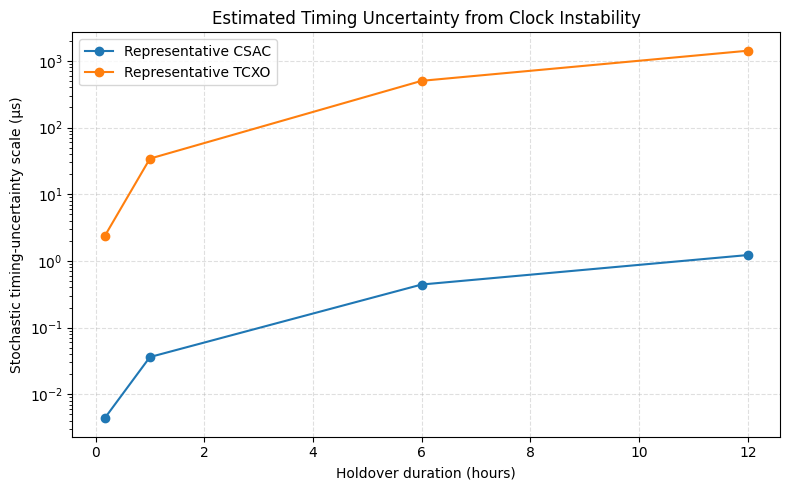

In [15]:
# 7.2.1 Stochastic Timing-Uncertainty Plot

import matplotlib.pyplot as plt

time_hours = stochastic_df["Time (s)"] / 3600

plt.figure(figsize=(8, 5))

plt.plot(
    time_hours,
    stochastic_df["Representative CSAC sigma_x (us)"],
    marker="o",
    label="Representative CSAC"
)

plt.plot(
    time_hours,
    stochastic_df["Representative TCXO sigma_x (us)"],
    marker="o",
    label="Representative TCXO"
)

plt.yscale("log")

plt.xlabel("Holdover duration (hours)")
plt.ylabel("Stochastic timing-uncertainty scale (µs)")
plt.title("Estimated Timing Uncertainty from Clock Instability")

plt.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()

plt.show()

### 7.2.1 Interpretation of Stochastic Timing-Uncertainty Estimates

The representative CSAC model produces substantially lower stochastic timing uncertainty than the representative TCXO model over all investigated holdover intervals.

Using

$$
\sigma_x(\tau) \approx \tau \sigma_y(\tau),
$$

the estimated timing-uncertainty scales are:

| Holdover | Representative CSAC | Representative TCXO |
|---|---:|---:|
| 10 min | 0.0044 µs | 2.34 µs |
| 1 h | 0.036 µs | 34.2 µs |
| 6 h | 0.443 µs | 502 µs |
| 12 h | 1.22 µs | 1.42 ms |

The increasing separation at longer holdover intervals is mainly associated with the larger random-walk FM contribution of the representative TCXO model.

These results are order-of-magnitude timing-uncertainty estimates rather than exact accumulated timing-error predictions. In addition, the stochastic coefficients represent generic CSAC and TCXO models from Fernández et al. (2017), rather than fitted noise models for the specific SA.45s and IQD IQXT-220-1 TCXO used in the deterministic analysis.

# 8. Holdover Error Comparison

The previous sections evaluated four contributions to clock timing error:

$$
y(t)=y_0+y_{\mathrm{age}}(t)+y_T(t)+y_{\mathrm{stoch}}(t).
$$

These contributions represent different types of clock behaviour and cannot all be combined as known deterministic errors.

The baseline comparison therefore includes **ageing** and **stochastic frequency instability**, for which quantitative models are available. Residual initial frequency offset and temperature-dependent variation are treated separately because their actual values during the GNSS outage are not known.

The final comparison therefore distinguishes between:

1. a baseline holdover-error scale based on ageing and stochastic instability,
2. sensitivity to residual initial frequency offset, and
3. a temperature-dependent bounding case.


## 8.1 Baseline Holdover Comparison

The deterministic ageing contribution is

$$
x_{\mathrm{age}}(t)=\frac{1}{2}Dt^2,
$$

while the stochastic timing-error scale is approximated by

$$
\sigma_x(t)\approx t\sigma_y(t).
$$

Because ageing represents a systematic contribution while $\sigma_x$ represents a statistical uncertainty scale, they are not added directly. An indicative baseline holdover-error scale is calculated as

$$
x_{\mathrm{hold}}(t)
=
\sqrt{x_{\mathrm{age}}^2(t)+\sigma_x^2(t)}.
$$

This provides a consistent basis for comparing the CSAC and TCXO baseline models. It should be interpreted as an **indicative holdover-error scale**, rather than a complete prediction of clock timing error.

In [16]:
# 8.1 Baseline Holdover Error Comparison

import numpy as np
import pandas as pd

# Use the stochastic parameters defined in Section 7
csac_noise = noise_parameters["Representative CSAC"]
tcxo_noise = noise_parameters["Representative TCXO"]

holdover_comparison = []

for label, t in holdover_times.items():

    # Ageing contribution

    csac_age_s = ageing_timing_error(D_csac, t)
    tcxo_age_s = ageing_timing_error(D_tcxo, t)

    # Stochastic contribution

    csac_sigma_y = allan_deviation(
        t,
        csac_noise["h0"],
        csac_noise["h_minus1"],
        csac_noise["h_minus2"]
    )

    tcxo_sigma_y = allan_deviation(
        t,
        tcxo_noise["h0"],
        tcxo_noise["h_minus1"],
        tcxo_noise["h_minus2"]
    )

    # Approximate stochastic timing-uncertainty scale
    csac_stoch_s = t * csac_sigma_y
    tcxo_stoch_s = t * tcxo_sigma_y

    # Indicative baseline holdover-error scale

    csac_total_s = np.sqrt(
        csac_age_s**2 + csac_stoch_s**2
    )

    tcxo_total_s = np.sqrt(
        tcxo_age_s**2 + tcxo_stoch_s**2
    )

    holdover_comparison.append({
        "Holdover": label,
        "Time (s)": t,

        "CSAC ageing (us)": csac_age_s * 1e6,
        "CSAC stochastic (us)": csac_stoch_s * 1e6,
        "CSAC indicative holdover scale (us)": csac_total_s * 1e6,

        "TCXO ageing (us)": tcxo_age_s * 1e6,
        "TCXO stochastic (us)": tcxo_stoch_s * 1e6,
        "TCXO indicative holdover scale (us)": tcxo_total_s * 1e6
    })

holdover_comparison_df = pd.DataFrame(
    holdover_comparison
)

holdover_comparison_df

,Holdover,Time (s),CSAC ageing (us),CSAC stochastic (us),CSAC indicative holdover scale (us),TCXO ageing (us),TCXO stochastic (us),TCXO indicative holdover scale (us)
0,10 min,600,0.000062,0.004356,0.004356,0.041667,2.343183,2.343554
1,1 h,3600,0.002250,0.036179,0.036249,1.500000,34.201959,34.234836
2,6 h,21600,0.081000,0.442637,0.449987,54.000000,502.084688,504.980231
3,12 h,43200,0.324000,1.224617,1.266753,216.000000,1419.945978,1436.280815


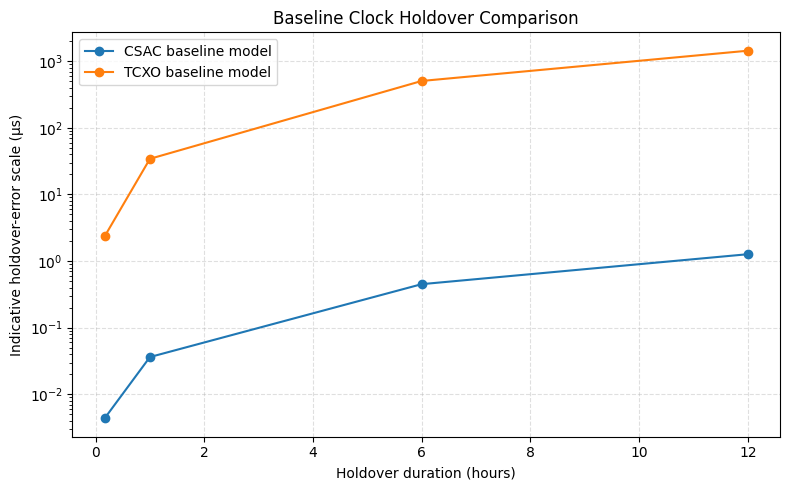

In [17]:

# 8.1.1 Baseline Holdover Comparison Plot

import matplotlib.pyplot as plt

time_hours = (
    holdover_comparison_df["Time (s)"] / 3600
)

plt.figure(figsize=(8, 5))

plt.plot(
    time_hours,
    holdover_comparison_df[
        "CSAC indicative holdover scale (us)"
    ],
    marker="o",
    label="CSAC baseline model"
)

plt.plot(
    time_hours,
    holdover_comparison_df[
        "TCXO indicative holdover scale (us)"
    ],
    marker="o",
    label="TCXO baseline model"
)

plt.yscale("log")

plt.xlabel("Holdover duration (hours)")
plt.ylabel("Indicative holdover-error scale (µs)")

plt.title(
    "Baseline Clock Holdover Comparison"
)

plt.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()

plt.show()

### 8.1.1 Interpretation of Baseline Holdover Results

The baseline model shows a substantially smaller indicative holdover-error scale for the CSAC than for the TCXO over all investigated holdover durations.

| Holdover | CSAC baseline | TCXO baseline |
|---|---:|---:|
| 10 min | 0.00436 $\mu$s | 2.34 $\mu$s |
| 1 h | 0.0362 $\mu$s | 34.3 $\mu$s |
| 6 h | 0.450 $\mu$s | 505 $\mu$s |
| 12 h | 1.27 $\mu$s | 1.44 ms |

For both clock models, stochastic frequency instability is larger than the ageing contribution over the investigated intervals. The CSAC baseline remains substantially lower than the TCXO baseline at all four holdover durations, showing the holdover advantage predicted by the representative CSAC model.

These baseline values do not include residual initial frequency offset or temperature-dependent frequency variation, which are considered separately below.

## 8.2 Influence of Initial Frequency Offset and Temperature

The baseline comparison does not imply that ageing and stochastic instability are the only sources of timing error. Residual initial frequency offset and temperature-dependent frequency variation can also influence holdover performance, but the available data do not support assigning a unique operating value to either contribution.

### Initial Frequency Offset

As shown in Section 6.2, a residual fractional-frequency offset produces timing error according to

$$
|x_{\mathrm{offset}}(t)|=|y_0|t.
$$

Its importance therefore depends directly on the frequency condition at the beginning of the GNSS outage.

For example, after 12 hours, a residual offset of

$$
|y_0|=10^{-10}
$$

would produce

$$
|x_{\mathrm{offset}}|=4.32~\mu\mathrm{s}.
$$

This is larger than the CSAC baseline holdover scale of approximately

$$
1.27~\mu\mathrm{s}
$$

over the same interval. The comparison shows that sufficiently large residual initial offset can become an important contribution during extended holdover.

### Temperature-Dependent Frequency Variation

Section 6.3 evaluated the manufacturer temperature specifications as bounding cases. At 12 hours, maintaining the full specified temperature-related frequency deviation throughout the holdover interval would correspond to timing-error bounds of approximately

$$
21.6~\mu\mathrm{s}
$$

for the SA.45s and

$$
12.096~\mathrm{ms}
$$

for the representative TCXO.

These values should not be interpreted as expected timing errors. They are bounding calculations based on manufacturer specifications. A realistic temperature contribution would require the actual temperature history and frequency-temperature response of each oscillator.


## 8.3 Summary of Holdover Contributions

The holdover analysis therefore provides three complementary results:

- **Baseline holdover scale:** combines the modelled ageing and stochastic contributions and provides the main CSAC–TCXO comparison.
- **Initial-offset sensitivity:** shows how uncertainty in the frequency condition at the start of holdover can affect accumulated timing error.
- **Temperature bound:** shows the potential magnitude of temperature-dependent error under the manufacturer specification limits.

The baseline comparison indicates substantially better holdover performance for the CSAC model than for the TCXO model. However, the sensitivity analyses show that initial frequency offset and temperature can also become important under unfavourable conditions.

These quantities are presented separately because they do not represent equivalent deterministic or statistical contributions and should not be added directly to form a single predicted timing error.

In [18]:
# 8.3 Summary of Holdover Contributions

summary_results = []

for label, t in holdover_times.items():

    # Baseline values
    baseline_row = holdover_comparison_df[
        holdover_comparison_df["Holdover"] == label
    ].iloc[0]

    # Temperature bounds
    temp_row = temperature_df[
        temperature_df["Holdover"] == label
    ].iloc[0]

    # Initial-offset sensitivity case: |y0| = 1e-10
    offset_sensitivity = (
        offset_timing_error(1e-10, t) * 1e6
    )

    summary_results.append({

        "Holdover": label,

        "CSAC baseline (us)":
            baseline_row[
                "CSAC indicative holdover scale (us)"
            ],

        "TCXO baseline (us)":
            baseline_row[
                "TCXO indicative holdover scale (us)"
            ],

        "Offset sensitivity, |y0|=1e-10 (us)":
            offset_sensitivity,

        "CSAC temperature bound (us)":
            temp_row[
                "CSAC temperature bound (us)"
            ],

        "TCXO temperature bound (us)":
            temp_row[
                "TCXO temperature bound (us)"
            ]
    })


summary_df = pd.DataFrame(summary_results)

summary_df

,Holdover,CSAC baseline (us),TCXO baseline (us),"Offset sensitivity, |y0|=1e-10 (us)",CSAC temperature bound (us),TCXO temperature bound (us)
0,10 min,0.004356,2.343554,0.06,0.3,168.0
1,1 h,0.036249,34.234836,0.36,1.8,1008.0
2,6 h,0.449987,504.980231,2.16,10.8,6048.0
3,12 h,1.266753,1436.280815,4.32,21.6,12096.0


The $|y_0|=10^{-10}$ column is included only as an illustrative sensitivity case and is not assigned as the actual residual frequency offset of either clock.

The summary demonstrates why initial frequency condition and environmental sensitivity remain important when interpreting holdover performance. Although the baseline model predicts substantially lower timing uncertainty for the representative CSAC, the total timing behaviour of a real clock also depends on its state at the beginning of holdover and the environmental conditions experienced during the GNSS outage.

For this reason, the baseline, initial-offset sensitivity and temperature bound are retained as separate results rather than combined into a single total-error prediction.

## 8.4 Comparison with Published Experimental Holdover Performance

To assess whether the baseline model produces a physically reasonable timing-error scale, its results are compared with independent experimental CSAC holdover measurements reported by Kim and Walter (2017).

Kim and Walter measured accumulated clock error for multiple CSAC units following GPS disciplining over periods of several days. Their measurements therefore provide an experimental reference for the magnitude and development of CSAC timing error during holdover.

The main analysis in this study remains limited to GNSS outages of 10 minutes, 1 hour, 6 hours and 12 hours. For this comparison only, the baseline model is extended to 24, 48 and 72 hours to cover the longer durations reported in the experimental study. These additional durations are not used in the underwater ranging analysis.

The comparison considers only the baseline model developed in Section 8.1,

$$
x_{\mathrm{hold}}(t)
=
\sqrt{
x_{\mathrm{age}}^2(t)
+
\sigma_x^2(t)
},
$$

which combines the modelled ageing contribution with the approximate stochastic timing-uncertainty scale. Initial frequency offset and temperature are not added because their actual values during the GNSS outage are unknown and are treated separately as sensitivity cases.

The comparison is therefore intended as a consistency check of the baseline timing-error scale rather than an exact reproduction of the experimental clock behaviour.

In [24]:

validation_times = {
    "12 h": 12 * 3600,
    "24 h": 24 * 3600,
    "48 h": 48 * 3600,
    "72 h": 72 * 3600
}

validation_results = []

for label, t in validation_times.items():

    # Ageing contribution
    csac_age_s = ageing_timing_error(
        D_csac,
        t
    )

    # Stochastic contribution
    csac_sigma_y = allan_deviation(
        t,
        csac_noise["h0"],
        csac_noise["h_minus1"],
        csac_noise["h_minus2"]
    )

    csac_stoch_s = t * csac_sigma_y

    # Same baseline model used in Section 8.1
    csac_baseline_s = np.sqrt(
        csac_age_s**2 +
        csac_stoch_s**2
    )

    validation_results.append({
        "Duration": label,
        "Ageing contribution (us)": csac_age_s * 1e6,
        "Stochastic scale (us)": csac_stoch_s * 1e6,
        "Baseline model scale (us)": csac_baseline_s * 1e6
    })

validation_df = pd.DataFrame(validation_results)

validation_df

,Duration,Ageing contribution (us),Stochastic scale (us),Baseline model scale (us)
0,12 h,0.324,1.224617,1.266753
1,24 h,1.296,3.424544,3.661573
2,48 h,5.184,9.630258,10.936897
3,72 h,11.664,17.657628,21.162248


### 8.4.1 Interpretation of the Experimental Comparison

Kim and Walter (2017) experimentally characterised the holdover behaviour of multiple CSAC units following GPS disciplining. They reported that, with a 30 s disciplining time constant, the clock errors of both tested CSAC types, except one unit, drifted within

$$
20~\mu\mathrm{s}
$$

over three days at room temperature.

For comparison, the baseline model developed in this notebook was extended beyond the 12-hour analysis interval to 72 hours. At 72 hours, the model gives an indicative holdover-error scale of approximately

$$
21.16~\mu\mathrm{s}.
$$

This value is comparable in scale to the $20~\mu\mathrm{s}$ drift reported for most of the experimentally tested CSAC units. This provides a broad consistency check that the model produces a physically reasonable timing-error scale over an extended holdover period.

However, this comparison should **not** be interpreted as direct numerical agreement or validation of the model. The experimental result describes the observed behaviour of physical CSAC units under specific test conditions, whereas the baseline model combines only the modelled ageing and stochastic contributions.

In addition, the reported $20~\mu\mathrm{s}$ value describes the clock drift over the three-day test period, rather than a measured timing error of exactly $20~\mu\mathrm{s}$ at 72 hours.

Residual initial frequency offset and temperature-dependent frequency variation are also treated separately in this notebook because their actual values during holdover are not known.

The experimental comparison therefore provides a **broad consistency check on the physical scale of the model**, rather than an exact validation of its predicted timing error.

# 9. Underwater One-Way Acoustic Ranging Application

The holdover analysis in the previous sections quantified how clock timing uncertainty develops after GNSS timing is lost. This section translates those clock-domain results into an equivalent ranging error for an underwater one-way acoustic travel-time (OWTT) scenario.

## 9.1 Underwater Scenario and One-Way Travel-Time Ranging

An autonomous underwater vehicle (AUV) cannot receive GNSS signals while submerged. A representative operating scenario is therefore considered in which the AUV clock is synchronised to GNSS before submergence and subsequently operates in holdover.

This scenario is consistent with published underwater acoustic-navigation experiments. Kebkal et al. (2017) demonstrated one-way acoustic travel-time ranging using a Microsemi SA.45 chip-scale atomic clock (CSAC) integrated with an acoustic modem. Rypkema et al. (2022) similarly used SA.45s CSACs on AUVs, with the clocks synchronised to GPS before deployment and maintained in holdover during underwater operation.

For one-way ranging, an acoustic signal is transmitted at a known time $t_{\mathrm{tx}}$ and received by the AUV at time $t_{\mathrm{rx}}$. The measured one-way travel time is

$$
T_{\mathrm{OWTT}} = t_{\mathrm{rx}} - t_{\mathrm{tx}}.
$$

If the effective speed of sound in water is $c_s$, the corresponding acoustic range is

$$
r = c_s T_{\mathrm{OWTT}}.
$$

Unlike two-way ranging, the transmitter and receiver do not determine range from a round-trip measurement. Their clocks must therefore share a sufficiently accurate time reference. If the AUV clock accumulates a timing error during GNSS-denied holdover, this error appears directly in the measured one-way travel time and consequently in the inferred range.

The purpose of the following analysis is therefore to determine the **range-equivalent error caused by clock holdover uncertainty**. It does not attempt to predict the complete underwater navigation error, which can also be influenced by acoustic propagation, sound-speed variation, environmental conditions, vehicle motion, sensor errors and navigation processing.

## 9.2 Clock Timing Error and Range-Equivalent Error

The one-way acoustic range is calculated from the measured travel time as

$$
r = c_s T_{\mathrm{OWTT}}.
$$

Suppose the AUV clock has accumulated a timing error $\Delta t_{\mathrm{clock}}$ while operating in holdover. This timing error introduces an equivalent error into the measured acoustic travel time.

The corresponding clock-induced range-equivalent error is therefore

$$
\Delta r_{\mathrm{clock}} = c_s \Delta t_{\mathrm{clock}}.
$$

This relationship shows that timing error is converted directly into range error through the speed of sound in water. For example, a clock timing error of $1~\mu\mathrm{s}$ corresponds to a range-equivalent error of approximately

$$
\Delta r_{\mathrm{clock}}
=
(1481~\mathrm{m/s})(1\times10^{-6}~\mathrm{s})
=
1.481\times10^{-3}~\mathrm{m},
$$

or approximately

$$
1.48~\mathrm{mm}.
$$

For the following calculations, an effective sound speed of

$$
c_s = 1481~\mathrm{m/s}
$$

is used. This value is consistent with the experimentally calibrated effective sound speed reported by Rypkema et al. (2022) for their underwater acoustic-ranging experiments.

The sound speed is treated as a fixed scenario parameter in this analysis. Therefore, the calculated values represent **clock-induced range-equivalent error only**. Uncertainty caused by variations or errors in the assumed sound speed is outside the scope of the present clock-holdover model.

## 9.3 Baseline Clock-Induced Range-Equivalent Error

The baseline holdover comparison in Section 8 provides an indicative timing-error scale for each clock based on the modelled ageing and stochastic frequency-instability contributions.

To examine the implication for one-way acoustic ranging, each baseline timing-error scale is converted to a range-equivalent error using

$$
\Delta r_{\mathrm{baseline}} = c_s x_{\mathrm{hold}},
$$

where $x_{\mathrm{hold}}$ is the indicative baseline holdover-error scale and $c_s = 1481~\mathrm{m/s}$.

Because the baseline timing results are stored in microseconds, they are first converted to seconds before applying the range conversion.

The resulting quantity represents the magnitude of acoustic ranging error that would be equivalent to the modelled clock timing uncertainty. It remains a **clock-induced range-equivalent error**, rather than a prediction of total AUV ranging or navigation error.

In [19]:
# 9.3 Baseline Clock-Induced Range-Equivalent Error

import pandas as pd

# Effective sound speed from the representative underwater scenario
sound_speed = 1481.0  # m/s

range_results = []

for _, row in holdover_comparison_df.iterrows():

    # Convert baseline timing-error scales from microseconds to seconds
    csac_time_s = (
        row["CSAC indicative holdover scale (us)"] * 1e-6
    )

    tcxo_time_s = (
        row["TCXO indicative holdover scale (us)"] * 1e-6
    )

    # Convert clock timing error to range-equivalent error
    csac_range_m = sound_speed * csac_time_s
    tcxo_range_m = sound_speed * tcxo_time_s

    range_results.append({
        "Holdover": row["Holdover"],
        "CSAC baseline timing (us)": (
            row["CSAC indicative holdover scale (us)"]
        ),
        "CSAC range-equivalent error (m)": csac_range_m,
        "TCXO baseline timing (us)": (
            row["TCXO indicative holdover scale (us)"]
        ),
        "TCXO range-equivalent error (m)": tcxo_range_m
    })

baseline_range_df = pd.DataFrame(range_results)

baseline_range_df

,Holdover,CSAC baseline timing (us),CSAC range-equivalent error (m),TCXO baseline timing (us),TCXO range-equivalent error (m)
0,10 min,0.004356,0.000006,2.343554,0.003471
1,1 h,0.036249,0.000054,34.234836,0.050702
2,6 h,0.449987,0.000666,504.980231,0.747876
3,12 h,1.266753,0.001876,1436.280815,2.127132


### 9.3.1 Interpretation of Baseline Range-Equivalent Results

The results show that the representative CSAC produces a substantially smaller clock-induced range-equivalent error than the representative TCXO across all investigated holdover durations.

The difference between the two clock models becomes increasingly significant as the GNSS outage becomes longer. This reflects the lower ageing contribution and stochastic frequency instability predicted for the representative CSAC model.

For the underwater one-way ranging scenario, this indicates that improved clock holdover stability can substantially reduce the ranging error introduced by loss of timing synchronisation during extended GNSS-denied operation.

These values represent **clock-induced range-equivalent error only**. They do not represent the total ranging or positioning accuracy of the AUV, which can also be affected by acoustic propagation, sound-speed variation, environmental conditions, vehicle motion, sensor errors and navigation processing.

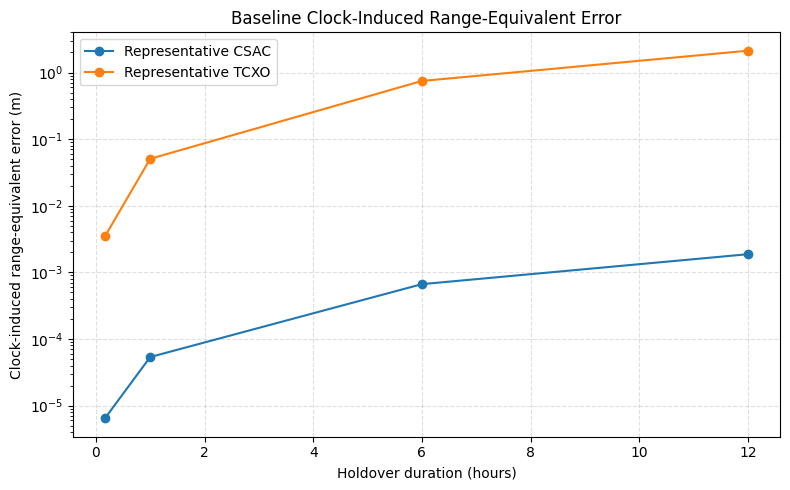

In [20]:
# 9.3.2 Baseline Range-Equivalent Error Plot

import matplotlib.pyplot as plt

time_hours = holdover_comparison_df["Time (s)"] / 3600

plt.figure(figsize=(8, 5))

plt.plot(
    time_hours,
    baseline_range_df["CSAC range-equivalent error (m)"],
    marker="o",
    label="Representative CSAC"
)

plt.plot(
    time_hours,
    baseline_range_df["TCXO range-equivalent error (m)"],
    marker="o",
    label="Representative TCXO"
)

plt.yscale("log")

plt.xlabel("Holdover duration (hours)")
plt.ylabel("Clock-induced range-equivalent error (m)")
plt.title("Baseline Clock-Induced Range-Equivalent Error")

plt.grid(
    True,
    which="major",
    linestyle="--",
    alpha=0.4
)

plt.legend()
plt.tight_layout()

plt.show()

The logarithmic scale highlights the increasing separation between the CSAC and TCXO clock-induced range-equivalent errors as the holdover duration increases.

## 9.4 Initial-Frequency-Offset Sensitivity in Acoustic Range

Section 6.2 showed that a residual fractional-frequency offset at the beginning of holdover produces an accumulated timing error that increases linearly with time.

The corresponding effect on one-way acoustic ranging can be expressed as

$$
\Delta r_{\mathrm{offset}}
=
c_s |y_0|t.
$$

The same hypothetical offset cases considered in Section 6.2 are converted here to range-equivalent errors. These cases are retained as a **sensitivity analysis** and are not assigned as measured residual offsets of either clock.

In [21]:
# 9.4 Initial-Frequency-Offset Range Sensitivity

offset_range_df = offset_df.copy()

for y0 in y0_cases:

    timing_column = f"y0 = {y0:.0e} (us)"
    range_column = f"|y0| = {y0:.0e} range error (m)"

    # Convert timing error from microseconds to seconds,
    # then convert to range-equivalent error
    offset_range_df[range_column] = (
        offset_range_df[timing_column]
        * 1e-6
        * sound_speed
    )

offset_range_df[
    [
        "Holdover",
        "|y0| = 1e-12 range error (m)",
        "|y0| = 1e-11 range error (m)",
        "|y0| = 1e-10 range error (m)",
        "|y0| = 1e-09 range error (m)"
    ]
]

,Holdover,|y0| = 1e-12 range error (m),|y0| = 1e-11 range error (m),|y0| = 1e-10 range error (m),|y0| = 1e-09 range error (m)
0,10 min,8.886000e-07,0.000009,0.000089,0.000889
1,1 h,5.331600e-06,0.000053,0.000533,0.005332
2,6 h,3.198960e-05,0.000320,0.003199,0.031990
3,12 h,6.397920e-05,0.000640,0.006398,0.063979


### 9.4.1 Interpretation of Initial-Frequency-Offset Sensitivity

The results show that the range-equivalent error increases linearly with both the residual initial fractional-frequency offset and the holdover duration.

This demonstrates that the clock condition at the beginning of a GNSS outage can influence one-way acoustic ranging during extended holdover. However, these values are sensitivity cases rather than predicted ranging errors, because the actual residual frequency offset after GNSS synchronisation has not been specified.

The initial-frequency-offset contribution is therefore retained separately from the baseline range-equivalent error.

## 9.5 Temperature Sensitivity in Acoustic Range

Section 6.3 examined the manufacturer-specified temperature-dependent frequency variation as a bounding case. The corresponding effect on one-way acoustic ranging can be expressed by converting the temperature-induced timing-error bound into an equivalent range error:

$$
\Delta r_{\mathrm{temp}} = c_s |x_{\mathrm{temp}}|.
$$

This conversion does not represent the expected ranging error during an underwater mission. It shows the potential range-equivalent effect if the specified temperature-related frequency deviation were maintained throughout the holdover interval.

In [22]:
# 9.5 Temperature Sensitivity in Acoustic Range

temperature_range_results = []

for _, row in temperature_df.iterrows():

    csac_range_m = (
        row["CSAC temperature bound (us)"] * 1e-6 * sound_speed
    )

    tcxo_range_m = (
        row["TCXO temperature bound (us)"] * 1e-6 * sound_speed
    )

    temperature_range_results.append({
        "Holdover": row["Holdover"],
        "CSAC temperature range bound (m)": csac_range_m,
        "TCXO temperature range bound (m)": tcxo_range_m
    })

temperature_range_df = pd.DataFrame(temperature_range_results)

temperature_range_df

,Holdover,CSAC temperature range bound (m),TCXO temperature range bound (m)
0,10 min,0.000444,0.248808
1,1 h,0.002666,1.492848
2,6 h,0.015995,8.957088
3,12 h,0.031990,17.914176


### 9.5.1 Interpretation of Temperature Sensitivity

The temperature bounding case shows a substantially larger potential range-equivalent effect for the representative TCXO than for the SA.45s CSAC.

However, these results should not be interpreted as expected acoustic ranging errors. They assume that the full manufacturer-specified temperature-related frequency deviation persists throughout the entire holdover interval. The actual contribution would depend on the temperature history experienced during the mission and the frequency–temperature response of the oscillator.

The results therefore illustrate sensitivity to temperature-dependent frequency variation rather than predict a specific underwater ranging error.

## 9.6 Relation to Published Underwater Experiments

The conversion of clock timing error into one-way acoustic range-equivalent error is supported by published underwater experiments.

Kebkal et al. (2017) demonstrated one-way acoustic travel-time ranging using a Microsemi SA.45 CSAC integrated with an underwater acoustic modem. This provides experimental evidence that CSAC timing can support one-way acoustic ranging when a sufficiently stable shared time reference is required.

Rypkema et al. (2022) demonstrated a related approach using SA.45s CSACs installed on autonomous underwater vehicles. The clocks were synchronised using GPS before deployment and subsequently maintained timing during underwater operation, where GPS was unavailable. This closely reflects the timing scenario considered in the present analysis.

However, the range-equivalent errors calculated in this study represent only the contribution associated with clock timing error:

$$
\Delta r_{\mathrm{clock}}
=
c_s \Delta t_{\mathrm{clock}}.
$$

They should not be interpreted as total underwater ranging or navigation error. The experimental systems reported by Kebkal et al. and Rypkema et al. are additionally affected by acoustic propagation, sound-speed uncertainty, vehicle motion, sensor errors and navigation processing.

The published experiments therefore support the practical relevance of applying CSAC holdover performance to one-way acoustic ranging, while the present model specifically isolates the contribution associated with clock stability.

# References

Calero, D., & Fernández, E. (2015). Characterization of chip-scale atomic clock for GNSS navigation solutions. *Proceedings of the 28th International Technical Meeting of the Satellite Division of the Institute of Navigation (ION GNSS+ 2015).*

Fernández, E., Calero, D., & Parés, M. E. (2017). CSAC characterization and its impact on GNSS clock augmentation performance. *Sensors, 17*(2), 370. https://doi.org/10.3390/s17020370

IQD Frequency Products. (n.d.). *IQXT-220-1 temperature compensated crystal oscillator (TCXO) datasheet*. IQD Frequency Products.

Kim, Y., & Walter, C. P. (2017). Retrace and disciplining time constant effects on holdover clock drifts in chip-scale atomic clock. *2017 Joint Conference of the European Frequency and Time Forum and IEEE International Frequency Control Symposium (EFTF/IFCS).* https://doi.org/10.1109/FCS.2017.8088878

Kebkal, K., Kebkal, O., Kebkal, V., & Komar, M. (2017). One-way travel-time acoustic localization of AUVs in the presence of clock drift. *OCEANS 2017 – Aberdeen.*

Microchip Technology Inc. (n.d.). *SA.45s chip scale atomic clock (CSAC), Options 001 and 003 datasheet*. Microchip Technology Inc.

Rypkema, N. R., Fischell, E. M., & Schmidt, H. (2022). Synchronous-clock range-angle relative acoustic navigation. *Field Robotics, 2*.